# 05 — ML (1/3) : Préparation, PCA, t-SNE/UMAP, K-Means exploratoire

*Notebook*

> **Dépendances :** Nécessite la table de features clients produite par **04_FeatureEngineering_Soldes_RAG.ipynb** (section 14).


## 0. Reprise depuis le notebook précédent

Nécessite `customers_features.csv`, exporté par **04_FeatureEngineering_Soldes_RAG.ipynb**.

In [1]:
import os, pickle, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

try:
    customers_features_full = pd.read_csv(os.path.join(INTERMEDIATE_DIR, "customers_features.csv"))
    print(f"customers_features_full chargé : {customers_features_full.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(
        "customers_features.csv introuvable dans INTERMEDIATE_DIR. Exécute 01 à 04 avant ce notebook."
    ) from e


Mounted at /content/drive
customers_features_full chargé : (1371980, 16)


## 17. Modélisation ML — Classification, Régression, Réduction de dimension et Clustering

On utilise ici `customers_features.csv` (section 14) pour construire et comparer plusieurs
modèles supervisés (classification + régression) et non supervisés (PCA, t-SNE, UMAP, K-Means).

**Échelle des données — bascule `FULL_SCALE` (cellule suivante) :**
- `FULL_SCALE = False` (défaut) : échantillon stratifié de 50 000 clients, adapté à un
  environnement contraint en RAM/CPU.
- `FULL_SCALE = True` (recommandé sur Colab avec suffisamment de RAM) : utilise l'intégralité des
  ~1,36M clients acheteurs pour l'entraînement des modèles qui passent à l'échelle (régression
  linéaire/régularisée, XGBoost/LightGBM/CatBoost, Random Forest, Arbre de décision, K-Means).

**Important — certaines méthodes restent bornées quelle que soit la RAM disponible**, car leur
complexité algorithmique (pas seulement mémoire) devient prohibitive au-delà de quelques dizaines
de milliers de points :
- **t-SNE** : reste sur un sous-échantillon de 5 000 clients (`viz_sample`).
- **Clustering hiérarchique** : reste sur un sous-échantillon de 2 000 clients (`hier_sample_idx`).
- **SVM et KNN** : restent sur un sous-échantillon de 50 000 lignes maximum (`Xtr_slow`), même en
  mode `FULL_SCALE`.
- **GridSearchCV** : la recherche d'hyperparamètres s'effectue sur ce même sous-échantillon borné,
  puis le modèle retenu est ré-entraîné avec les meilleurs paramètres sur l'ensemble complet.
- **SMOTE** : la classe majoritaire fournie à SMOTE est plafonnée à 100 000 lignes avant
  ré-équilibrage, pour éviter de générer plusieurs millions de lignes synthétiques.

Ces plafonds ne sont **pas des limitations de cet environnement en particulier** : même sur une
machine avec beaucoup plus de RAM (Colab, serveur dédié), t-SNE ou le clustering hiérarchique sur
1,36M points prendraient des heures, pas des minutes.


### 17.1 Préparation des données

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Réutilisation de la table déjà en mémoire (section 14) plutôt qu'une relecture du CSV
customers_features_ml = customers_features_full.dropna(subset=["total_spend"]).copy()

# --- BASCULE ÉCHELLE COMPLÈTE ---
# False (défaut, adapté à un environnement contraint) : échantillon stratifié de 50 000 clients.
# True (recommandé sur Colab avec >=12-25 Go de RAM) : utilise les ~1,36M clients acheteurs
#      pour l'entraînement des modèles supervisés (classification, régression, K-Means, GMM).
#      ATTENTION : certaines méthodes ne passent PAS à l'échelle même avec plus de RAM, car leur
#      complexité algorithmique (pas seulement mémoire) devient prohibitive au-delà de quelques
#      dizaines de milliers de points : t-SNE, le clustering hiérarchique, et le SVM restent donc
#      systématiquement calculés sur un sous-échantillon plus loin dans le notebook, quel que soit
#      ce réglage.
FULL_SCALE = True #False

if FULL_SCALE:
    ml_sample = customers_features_ml.copy()
else:
    SAMPLE_SIZE = 50_000
    ml_sample, _ = train_test_split(
        customers_features_ml, train_size=SAMPLE_SIZE,
        stratify=customers_features_ml["club_member_status"], random_state=42
    )

del customers_features_ml
gc.collect()

print(f"Échantillon de modélisation : {ml_sample.shape[0]:,} clients (FULL_SCALE={FULL_SCALE})")
print(ml_sample["club_member_status"].value_counts())

import gc as _gc; _gc.collect()

Échantillon de modélisation : 1,362,281 clients (FULL_SCALE=True)
club_member_status
ACTIVE        1269237
PRE-CREATE      92578
LEFT CLUB         466
Name: count, dtype: int64


0

In [3]:
# Features comportementales communes à toutes les méthodes non supervisées et à la classification
behavior_features = [
    "age", "n_transactions", "tenure_days", "n_distinct_categories",
    "avg_basket_value", "purchase_frequency_per_month", "recency_days",
]

X_behavior = ml_sample[behavior_features].fillna(0)
scaler = StandardScaler()
X_behavior_scaled = scaler.fit_transform(X_behavior)

print(f"Matrice de features : {X_behavior_scaled.shape}")

import gc as _gc; _gc.collect()

Matrice de features : (1362281, 7)


0

### 17.2 Réduction de dimension — PCA

In [4]:
from sklearn.decomposition import PCA
# PCA - 2D
pca = PCA(n_components=2, random_state=42)
pca_proj = pca.fit_transform(X_behavior_scaled)

print(f"Variance expliquée par les 2 premières composantes : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  - Composante 1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  - Composante 2 : {pca.explained_variance_ratio_[1]*100:.1f}%")

import gc as _gc; _gc.collect()

Variance expliquée par les 2 premières composantes : 58.5%
  - Composante 1 : 42.3%
  - Composante 2 : 16.3%


0

| Observation                | Analyse                                                                                                                                                                                                                     |
| -------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Première composante (PC1)  | La première composante explique **42,3% de la variance totale**. Elle représente donc l'axe principal de variation des profils clients et capture une grande partie de l'information contenue dans les variables initiales. |
| Deuxième composante (PC2)  | La deuxième composante ajoute **16,3% d'information supplémentaire**, permettant de mieux distinguer les profils clients selon une autre dimension comportementale.                                                         |
| Projection en 2 dimensions | Les deux premières composantes permettent de représenter **58,5% de l'information initiale** dans un espace 2D, ce qui constitue une représentation intéressante pour visualiser les groupes de clients.                    |


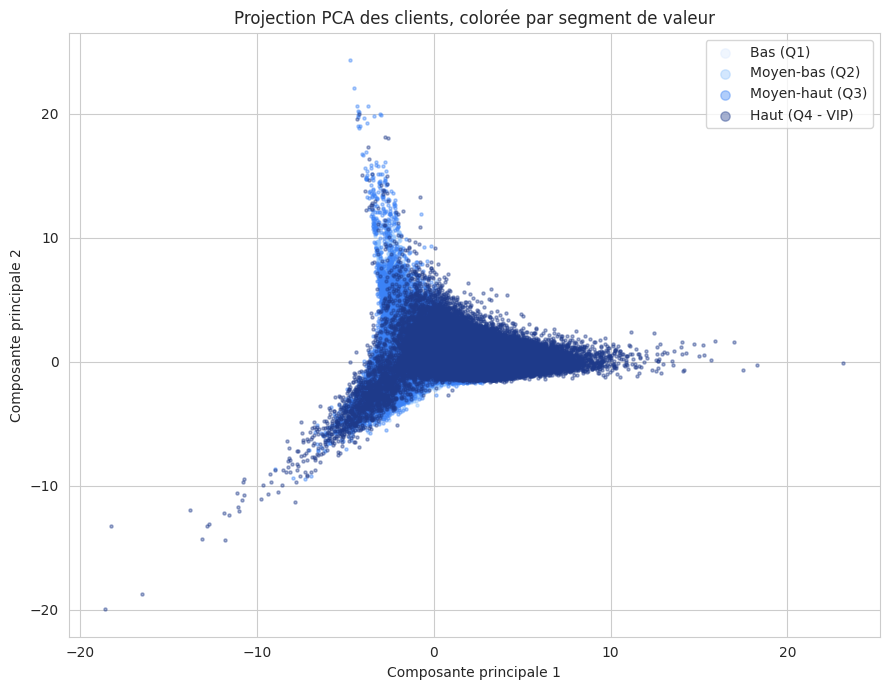

18

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
segments = ml_sample["segment_valeur"].values
palette = {"Bas (Q1)": "#dbeafe", "Moyen-bas (Q2)": "#93c5fd", "Moyen-haut (Q3)": "#3b82f6", "Haut (Q4 - VIP)": "#1e3a8a"}
for seg, color in palette.items():
    mask = segments == seg
    ax.scatter(pca_proj[mask, 0], pca_proj[mask, 1], s=5, alpha=0.4, color=color, label=seg)
ax.set_xlabel("Composante principale 1")
ax.set_ylabel("Composante principale 2")
ax.set_title("Projection PCA des clients, colorée par segment de valeur")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

**Interprétation :** si les segments de valeur se séparent visuellement le long de la composante 1, cela confirme que le comportement d'achat (fréquence, panier, ancienneté) porte l'essentiel du signal de segmentation cohérent avec la construction de `segment_valeur` à partir de `total_spend`.


*  Les clients VIP (Q4) forment un groupe relativement homogène, principalement situé dans la branche supérieure, ils partagent des caractéristiques communes fortes.
*  Les clients à faible valeur (Q1-Q2) sont très dispersés, ce qui suggère qu'il existe plusieurs raisons à leur faible valeur (nouveaux clients, clients en désengagement, clients occasionnels, etc.).

In [6]:
from sklearn.decomposition import PCA

# PCA - 3D
pca = PCA(n_components=3, random_state=42)
pca_proj = pca.fit_transform(X_behavior_scaled)

print(f"Variance expliquée par les 3 premières composantes : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  - Composante 1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  - Composante 2 : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  - Composante 3 : {pca.explained_variance_ratio_[2]*100:.1f}%")

import gc as _gc; _gc.collect()

Variance expliquée par les 3 premières composantes : 72.0%
  - Composante 1 : 42.3%
  - Composante 2 : 16.3%
  - Composante 3 : 13.5%


0

| Observation                | Analyse                                                                                                                                                                                                                                                     |
| -------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Première composante (PC1)  | La PC1 explique **42,3% de la variance totale**, ce qui signifie qu'elle capture la principale source de variation entre les profils clients. Elle représente probablement l'axe comportemental dominant (ex. intensité d'achat, valeur client, fréquence). |
| Deuxième composante (PC2)  | La PC2 ajoute **16,3% d'information supplémentaire** et permet de distinguer les clients selon une seconde dimension comportementale.                                                                                                                       |
| Troisième composante (PC3) | La PC3 contribue à hauteur de **13,5%**, apportant une dimension complémentaire pour mieux représenter la diversité des profils clients.                                                                                                                    |
| Projection 3D globale      | Les trois premières composantes conservent **72% de l'information initiale**, ce qui offre une représentation plus fidèle que la projection 2D (58,5%).                                                                                                     |


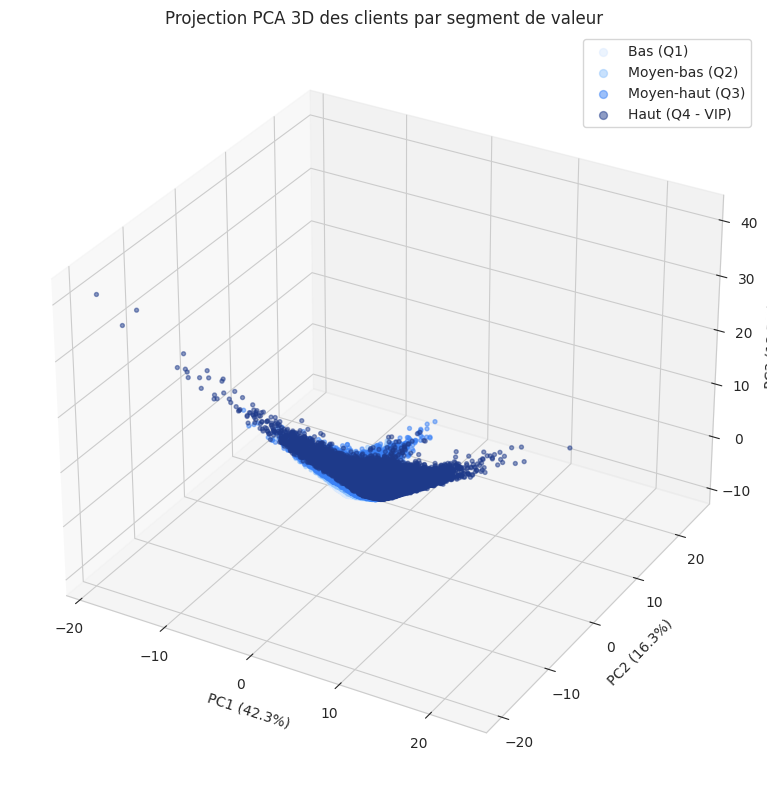

3806

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

segments = ml_sample["segment_valeur"].values

palette = {"Bas (Q1)": "#dbeafe","Moyen-bas (Q2)": "#93c5fd","Moyen-haut (Q3)": "#3b82f6","Haut (Q4 - VIP)": "#1e3a8a"}

for seg, color in palette.items():
    mask = segments == seg

    ax.scatter(pca_proj[mask, 0],pca_proj[mask, 1],pca_proj[mask, 2],s=8,alpha=0.5,color=color,label=seg)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")

ax.set_title("Projection PCA 3D des clients par segment de valeur")

ax.legend(markerscale=2)

plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

| Segment de valeur              | Position observée                                                       | Interprétation                                                                                                                       |
| ------------------------------ | ----------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| **Q4 - VIP (bleu foncé)**      | Concentré au centre-bas de la surface courbe                            | Profil relativement homogène, avec des valeurs modérées sur PC1 et PC2 mais une distinction plus marquée selon PC3.                  |
| **Q3 - Moyen-haut**            | Situé autour du centre, avec une légère dispersion                      | Segment de transition entre les clients VIP et les segments de valeur moyenne. Ces clients présentent un comportement intermédiaire. |
| **Q2 - Moyen-bas**             | Plus dispersé sur les bords de la surface PCA                           | Profils clients plus variés, avec des comportements d'achat moins homogènes.                                                         |
| **Q1 - Bas (bleu très clair)** | Réparti sur l'ensemble de la surface, y compris dans les zones extrêmes | Segment très hétérogène regroupant des clients aux comportements différents et à faible valeur d'achat.                              |


> La projection PCA met en évidence une structure progressive des segments de valeur : les clients VIP (Q4) présentent un comportement plus homogène, tandis que les segments de plus faible valeur (Q1 et Q2) montrent une plus grande diversité de profils. Cette séparation confirme que les variables comportementales utilisées capturent efficacement les différences d'engagement et de valeur client.



### 17.3 Visualisation avancée — t-SNE et UMAP

**t-SNE et UMAP : techniques de réduction de dimension pour visualiser les clients**

> Contrairement à la PCA, qui cherche à conserver la variance globale des données, t-SNE et UMAP sont des méthodes de réduction de dimension principalement utilisées pour visualiser des structures complexes dans des données de haute dimension.

**Comparaison PCA vs t-SNE vs UMAP**

| Méthode   | Objectif principal                       | Conservation de l'information        | Usage recommandé                              |
| --------- | ---------------------------------------- | ------------------------------------ | --------------------------------------------- |
| **PCA**   | Réduction linéaire de dimension          | Conserve la variance globale         | Prétraitement ML, analyse globale, clustering |
| **t-SNE** | Préserver les voisinages locaux          | Conserve les similarités locales     | Visualisation de groupes/clusters             |
| **UMAP**  | Préserver la structure locale et globale | Conserve mieux la structure générale | Visualisation + exploration + clustering      |


In [8]:
# t-SNE et UMAP sont plus coûteux : on utilise un sous-échantillon de 5 000 clients
viz_sample = ml_sample.sample(5000, random_state=42)
X_viz = scaler.transform(viz_sample[behavior_features].fillna(0))

import gc as _gc; _gc.collect()

0

In [9]:
from sklearn.manifold import TSNE
import time

t0 = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
tsne_proj = tsne.fit_transform(X_viz)
print(f"t-SNE calculé en {time.time()-t0:.0f}s")

import gc as _gc; _gc.collect()

t-SNE calculé en 65s


0

In [10]:
import umap

t0 = time.time()
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_proj = umap_model.fit_transform(X_viz)
print(f"UMAP calculé en {time.time()-t0:.0f}s")

import gc as _gc; _gc.collect()

UMAP calculé en 39s


66006

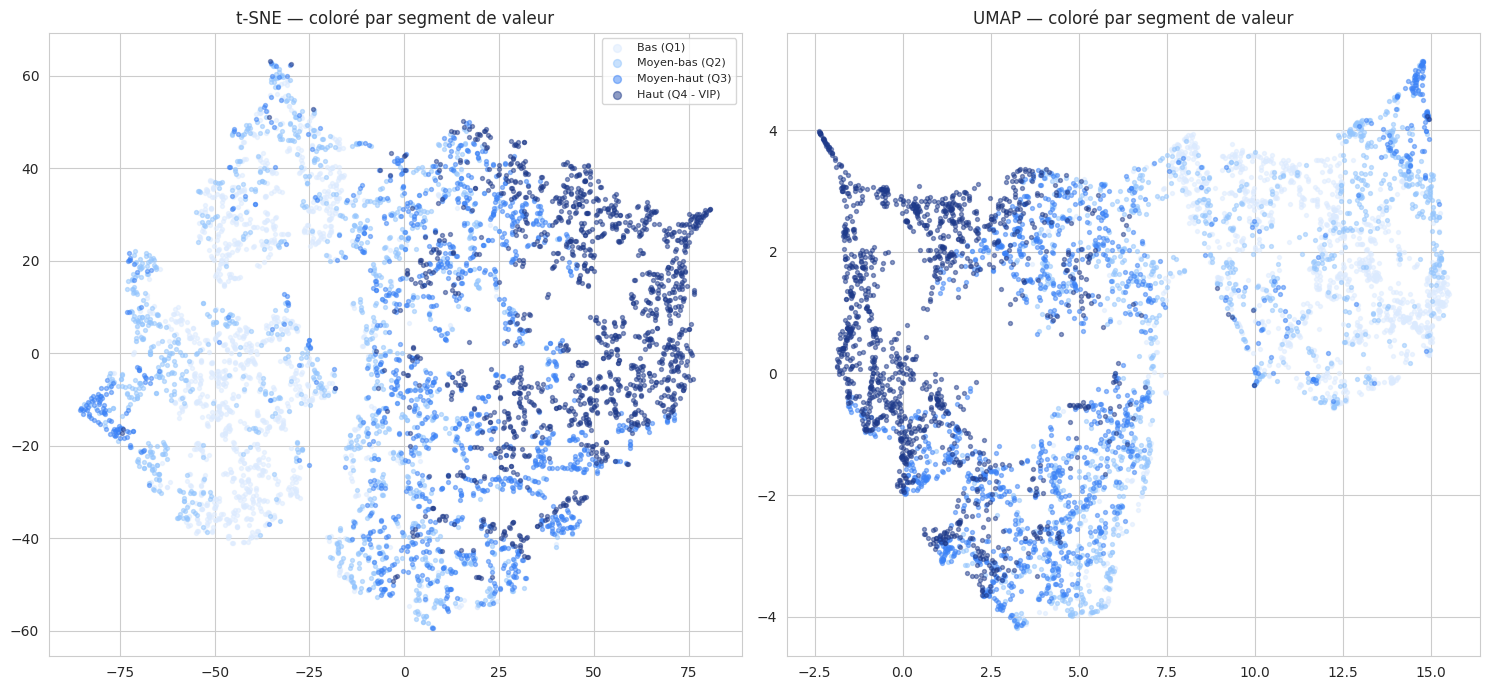

24

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for seg, color in palette.items():
    mask = viz_sample["segment_valeur"].values == seg
    axes[0].scatter(tsne_proj[mask, 0], tsne_proj[mask, 1], s=8, alpha=0.5, color=color, label=seg)
    axes[1].scatter(umap_proj[mask, 0], umap_proj[mask, 1], s=8, alpha=0.5, color=color, label=seg)

axes[0].set_title("t-SNE — coloré par segment de valeur")
axes[1].set_title("UMAP — coloré par segment de valeur")
axes[0].legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

**Interprétation :** t-SNE et UMAP donnent tous deux une vision non-linéaire de la structure
des données utile pour repérer des sous-groupes de clients qu'une simple séparation par quartile
(PCA linéaire) pourrait manquer.

Si les segments apparaissent comme des zones continues plutôt que
des clusters nettement séparés, cela confirme que la valeur client est un **spectre continu**, pas
des groupes naturellement distincts.

Une nuance importante pour le marketing (éviter de traiter
les frontières de segments comme des ruptures brutales).


**Interprétation du t-SNE**

| Observation                                | Interprétation                                                                                                                                                                          |
| ------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Séparation visuelle des groupes            | Le t-SNE montre une organisation des clients selon leurs comportements d'achat, avec une présence plus importante des clients VIP dans certaines zones spécifiques.                     |
| Concentration des clients VIP (bleu foncé) | Les clients Q4 apparaissent davantage regroupés dans plusieurs régions de la projection, ce qui indique des profils comportementaux relativement similaires.                            |
| Présence des segments intermédiaires       | Les segments Q2 et Q3 occupent des zones de transition entre les clients faibles valeurs et les VIP, ce qui reflète une progression graduelle de la valeur client.                      |
| Dispersion du segment Q1                   | Les clients à faible valeur sont répartis dans plusieurs zones, indiquant une forte diversité de comportements même parmi les clients peu actifs.                                       |
| Structure non linéaire                     | Les formes complexes observées montrent que les relations entre les variables comportementales ne sont pas simplement linéaires, ce qui justifie l'utilisation de méthodes comme t-SNE. |


**Interprétation de l'UMAP**
| Observation                                    | Interprétation                                                                                                                                                       |
| ---------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Structure globale plus lisible                 | UMAP révèle une organisation plus continue des profils clients, avec une meilleure visibilité des transitions entre les segments.                                    |
| Gradient de valeur client                      | On observe une évolution progressive des couleurs : les clients de faible valeur (clair) évoluent vers les clients VIP (foncé), suggérant un continuum d'engagement. |
| Clients VIP                                    | Les clients Q4 sont davantage concentrés dans certaines zones, notamment dans les régions où la densité de points foncés est plus élevée.                            |
| Segments Q2/Q3                                 | Ces groupes occupent une position intermédiaire, confirmant leur rôle de transition entre les clients occasionnels et les clients à forte valeur.                    |
| Meilleure conservation de la structure globale | UMAP permet de mieux visualiser les relations globales entre les profils clients que t-SNE.                                                                          |


**Comparaison t-SNE vs UMAP**
| Critère                     | t-SNE                                      | UMAP                                         |
| --------------------------- | ------------------------------------------ | -------------------------------------------- |
| Type de structure préservée | Relations locales entre clients similaires | Relations locales + structure globale        |
| Lecture des segments        | Bonne séparation des groupes               | Organisation plus progressive                |
| Interprétation métier       | Visualisation exploratoire                 | Plus adaptée à l'analyse des segments        |
| Stabilité                   | Plus sensible aux paramètres               | Généralement plus stable                     |
| Utilisation recommandée     | Exploration visuelle des clusters          | Analyse et communication des profils clients |


**Conclusion**

> Les projections t-SNE et UMAP confirment l'existence de structures comportementales différenciant les segments de valeur client. Les clients VIP (Q4) présentent des profils plus regroupés, tandis que les segments de faible valeur montrent une plus grande diversité comportementale. UMAP offre une représentation particulièrement intéressante en mettant en évidence un gradient continu entre les différents niveaux de valeur client. Ces résultats renforcent la pertinence des variables comportementales utilisées pour la segmentation et la personnalisation des recommandation

**Remarque importante :** t-SNE et UMAP sont principalement des outils de visualisation exploratoire. La séparation observée ne signifie pas automatiquement que les segments sont parfaitement séparables par un modèle, elle sert surtout à comprendre la structure des données avant un clustering ou un modèle de recommandation.

### 17.4 Clustering non supervisé — K-Means

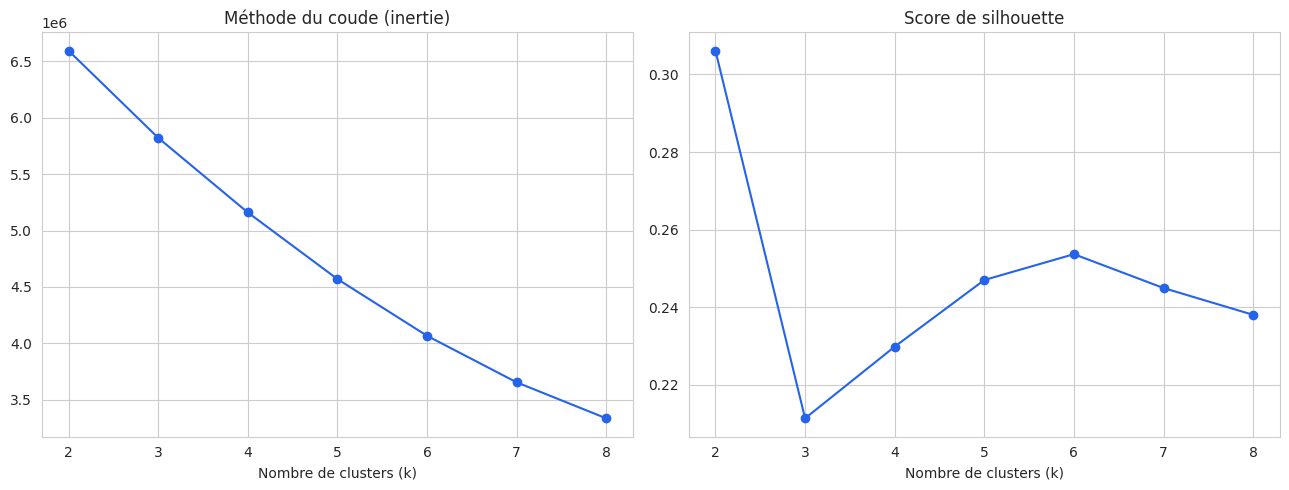

7454

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_behavior_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_behavior_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o", color="#2563eb")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de clusters (k)")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#2563eb")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters (k)")

plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

on préfère :

`Le plus petit k qui produit des segments distincts et utiles`

car :

- plus simple à expliquer
- plus facile à visualiser
- plus facile à exploiter dans une stratégie marketing.

**Choix du nombre de clusters**

Pour choisir le nombre optimal de clusters, on combine les deux critères :

- la méthode du coude indique un coude autour de k = 6 ;
- le score de silhouette est le meilleur parmi les segmentations détaillées (k ≥ 3) pour k = 6.

Les deux méthodes convergent statistiquement vers **k=6** pour cette analyse exploratoire rapide.

> ⚠️ Pour la suite de **cette sous-section (17.4)**, on retient volontairement **k=4** — pas k=6 — afin de comparer directement le clustering non supervisé à la segmentation par quartiles de la section 11 (4 groupes). Le choix statistiquement recommandé (k=6) est ré-exploré et confirmé rigoureusement dans la section 17.7 (clustering approfondi), avec K-Means, clustering hiérarchique et GMM.


**Interprétation métier**

Le choix de 6 clusters permet d'obtenir un compromis entre :

- une bonne compacité des groupes (faible inertie) ;
- une séparation satisfaisante des clusters (silhouette relativement élevée) ;
- une segmentation suffisamment détaillée pour distinguer différents profils de clients, sans créer un nombre excessif de groupes.

**Afin de déterminer le nombre optimal de clusters, deux critères ont été utilisés :** la méthode du coude et le score de silhouette. La méthode du coude montre que la diminution de l'inertie devient moins importante à partir de k = 6, ce qui indique un point de stabilisation. Par ailleurs, le score de silhouette atteint sa valeur maximale pour k = 2, mais cette solution produit une segmentation trop générale. Parmi les valeurs supérieures à 2, le meilleur score de silhouette est obtenu pour k = 6. En combinant ces deux critères, **k=6 est le choix statistiquement recommandé** par cette analyse exploratoire. Il est cependant volontairement mis de côté dans les deux cellules suivantes (17.4), où l'on retient **k=4** pour permettre une comparaison directe avec la segmentation par quartiles de la section 11 — k=6 sera repris et validé plus rigoureusement en section 17.7.



**Remarque :** le score de silhouette reste relativement faible (autour de 0,25), ce qui suggère que les profils clients se chevauchent partiellement. Cela est fréquent dans les données comportementales réelles, où les frontières entre les segments ne sont pas parfaitement distinctes. Malgré cela, la solution à 6 clusters constitue le meilleur compromis parmi les valeurs testées.

In [13]:
# NB : l'analyse ci-dessus recommande statistiquement k=6 (coude + silhouette).
# On retient volontairement k=4 ICI pour comparer directement le clustering non supervise
# a la segmentation par quartiles (section 11, 4 groupes). Le k=6 statistiquement optimal
# est repris et valide rigoureusement en section 17.7 (clustering approfondi).
K_OPTIMAL = 4
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
ml_sample = ml_sample.copy()
ml_sample["cluster_kmeans"] = kmeans_final.fit_predict(X_behavior_scaled)

cross_cluster_segment = pd.crosstab(ml_sample["cluster_kmeans"], ml_sample["segment_valeur"])
cross_cluster_segment

import gc as _gc; _gc.collect()

0

**Principe du clustering K-Means**

L'objectif de K-Means est de regrouper les données en k groupes (clusters) homogènes.

Chaque cluster possède un centre (centroïde). L'algorithme cherche à minimiser la distance entre les points et leur centroïde.

L'inertie correspond à :
$$
\text{Inertie} = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

où :
- $C_i$ : cluster i
- $x$ : un client
- $\mu_i$ : centre du cluster

Plus l'inertie est faible, plus les clients d'un même cluster sont proches.

**1. Méthode du coude (Elbow Method)**

- **Principe :** tracer l'inertie intra-classe (somme des distances au centre) en fonction de k.
- **Interprétation :** chercher le point où la courbe s'infléchit (le "coude").

On teste plusieurs valeurs de k

Pour chaque valeur :

* K-Means crée k clusters.
* On calcule l'inertie.
* On stocke le résultat.

> Le point où la courbe commence à ralentir forme le coude. Ce point correspond au nombre optimal de clusters.

**2. Score de silhouette**

La silhouette mesure si les clusters sont :

- compacts (clients proches dans le même groupe)
- séparés (clusters éloignés entre eux)

Le score est compris entre :

$$ -1 \leq \text{silhouette} \leq 1 $$

**Signification :**
| Score      | Interprétation              |
| ---------- | --------------------------- |
| ≈ 1        | Très bonne séparation       |
| 0.5 - 0.7  | Bonne segmentation          |
| 0.25 - 0.5 | Segmentation moyenne        |
| ≈ 0        | Clusters qui se chevauchent |
| <0         | Mauvais clustering          |


**3. Pourquoi utiliser les deux méthodes ?**

- La méthode du coude seule peut être ambiguë.
- La diminution d'inertie peut être similaire.

> Le score de silhouette permet de confirmer.

On cherche donc un compromis :
- Inertie qui commence à se stabiliser + Silhouette maximale

Une bonne règle :

- Silhouette maximale + coude visible → choisir ce k
- Si plusieurs k sont proches → choisir le plus petit k qui donne des segments interprétables

**4. Résumé**
| Méthode          | Question posée                                            | Meilleur choix               |
| ---------------- | --------------------------------------------------------- | ---------------------------- |
| Méthode du coude | Combien de clusters expliquent suffisamment la variance ? | Point où l'inertie ralentit  |
| Silhouette       | Les clusters sont-ils bien séparés ?                      | Score maximal                |
| Décision finale  | Quel k choisir ?                                          | Coude + meilleure silhouette |


**Interprétation :** ce tableau croisé permet de vérifier si les clusters K-Means
(purement basés sur la forme des données, sans connaître les quartiles) retrouvent naturellement
une structure proche des segments de valeur définis en section 11. Une forte correspondance
validerait la segmentation par quartiles comme une bonne approximation de la structure réelle des
données ; une correspondance faible indiquerait que d'autres dimensions (pas seulement le montant
dépensé) structurent davantage le comportement client.


## Export vers les notebooks suivants

`ml_sample`, `X_behavior_scaled`, `scaler` et `behavior_features` sont requis par les notebooks 06 (classification/régression) et 07 (clustering approfondi), pour repartir exactement du même échantillon/même normalisation.

In [14]:
ml_prep = {
    "ml_sample": ml_sample,
    "X_behavior_scaled": X_behavior_scaled,
    "scaler": scaler,
    "behavior_features": behavior_features,
}
with open(os.path.join(INTERMEDIATE_DIR, "nb05_ml_prep.pkl"), "wb") as f:
    pickle.dump(ml_prep, f)
print(f"Export -> nb05_ml_prep.pkl  (ml_sample: {ml_sample.shape}, X_behavior_scaled: {X_behavior_scaled.shape})")


Export -> nb05_ml_prep.pkl  (ml_sample: (1362281, 17), X_behavior_scaled: (1362281, 7))
